In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Steg 1: Förbered datasetet
data_path = r'data/breast-cancer.data'
columns = ["Class", "age", "menopause", "tumor-size", "inv-nodes", 
           "node-caps", "deg-malig", "breast", "breast-quad", "irradiat"]
data = pd.read_csv(data_path, header=None, names=columns)

# Omvandla kategoriska attribut till numeriska
label_encoders = {}
for col in data.columns:
    if data[col].dtype == "object":
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])
        label_encoders[col] = le

X = data.drop("Class", axis=1)
y = data["Class"]

# Steg 2: Uppgift a - Icke-normaliserat och normaliserat data
def run_decision_tree(X, y, normalize=False):
    if normalize:
        scaler = MinMaxScaler()
        X = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    clf = DecisionTreeClassifier(random_state=None)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    return acc, cm

# Kör för icke-normaliserat data
acc_original, cm_original = run_decision_tree(X, y, normalize=False)
print("Icke-normaliserat data")
print(f"Accuracy: {acc_original:.2f}")
print(f"Confusion Matrix:\n{cm_original}")

# Kör för normaliserat data
acc_normalized, cm_normalized = run_decision_tree(X, y, normalize=True)
print("\nNormaliserat data")
print(f"Accuracy: {acc_normalized:.2f}")
print(f"Confusion Matrix:\n{cm_normalized}")

Icke-normaliserat data
Accuracy: 0.64
Confusion Matrix:
[[30 10]
 [11  7]]

Normaliserat data
Accuracy: 0.59
Confusion Matrix:
[[25 10]
 [14  9]]


In [3]:
# Uppgift b - Kör 100 iterationer och beräkna medelvärden
def run_multiple_iterations(X, y, train_size, test_size, n_iterations=100):
    accuracies = []
    for _ in range(n_iterations):
        X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, test_size=test_size)
        clf = DecisionTreeClassifier(random_state=None)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    return np.mean(accuracies)

# Experiment 1: 75/25-split
mean_accuracy_75_25 = run_multiple_iterations(X, y, train_size=0.75, test_size=0.25)
print("\nMedelvärde för 75/25-split:")
print(f"Accuracy: {mean_accuracy_75_25:.2f}")

# Experiment 2: 67/33-split
mean_accuracy_67_33 = run_multiple_iterations(X, y, train_size=0.67, test_size=0.33)
print("\nMedelvärde för 67/33-split:")
print(f"Accuracy: {mean_accuracy_67_33:.2f}")



Medelvärde för 75/25-split:
Accuracy: 0.64

Medelvärde för 67/33-split:
Accuracy: 0.64


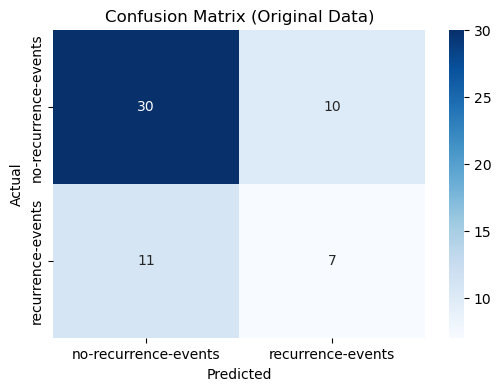

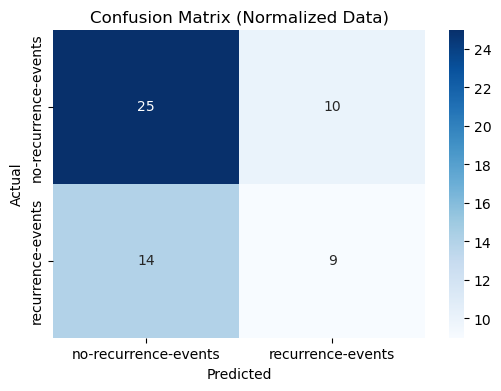

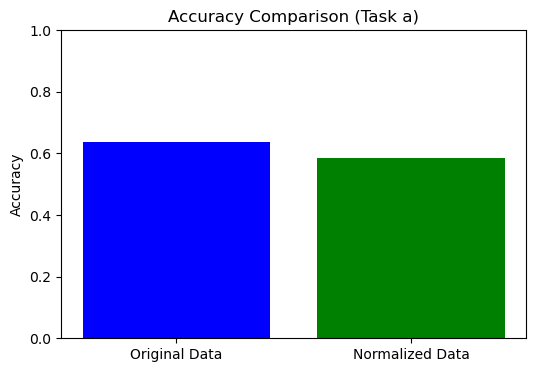

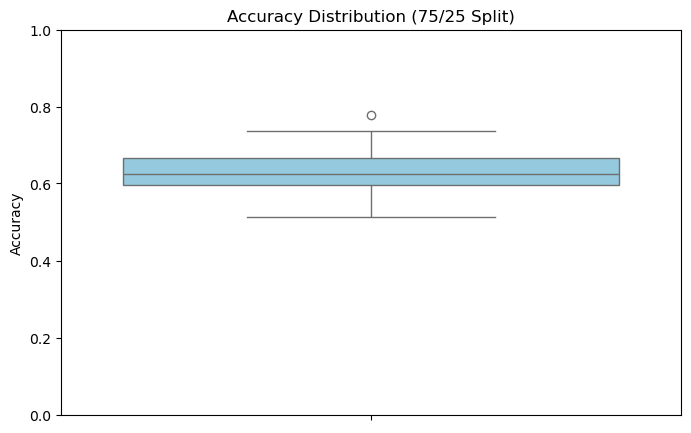

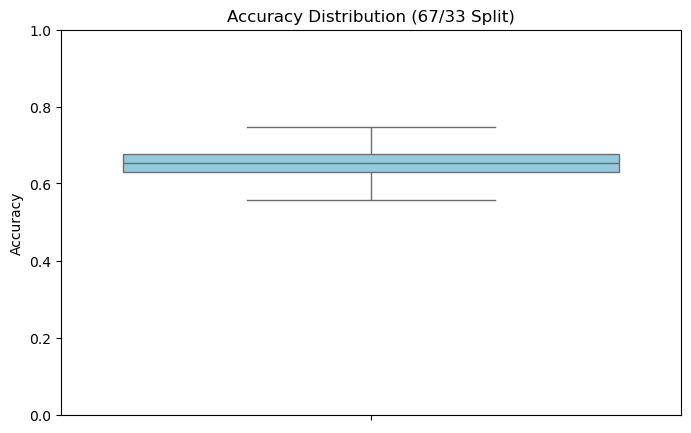

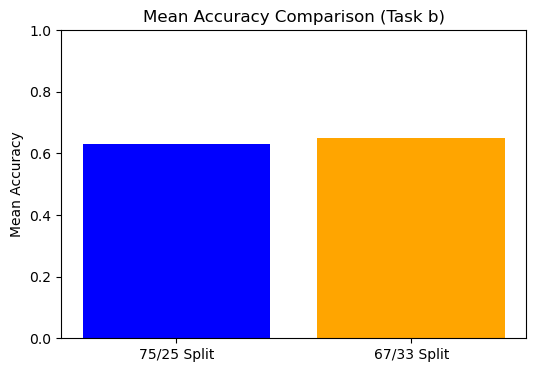

In [5]:
# Visualisering för uppgift a: Confusion Matrix och bar chart
def plot_confusion_matrix(cm, title, classes):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Plot Confusion Matrices för uppgift a
plot_confusion_matrix(cm_original, "Confusion Matrix (Original Data)", label_encoders["Class"].classes_)
plot_confusion_matrix(cm_normalized, "Confusion Matrix (Normalized Data)", label_encoders["Class"].classes_)

# Bar chart för Accuracy i uppgift a
plt.figure(figsize=(6, 4))
plt.bar(["Original Data", "Normalized Data"], [acc_original, acc_normalized], color=["blue", "green"])
plt.title("Accuracy Comparison (Task a)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

# Visualisering för uppgift b: Boxplot för Accuracy-spridning
def plot_accuracy_distribution(X, y, train_size, test_size, title, n_iterations=100):
    accuracies = []
    for _ in range(n_iterations):
        X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, test_size=test_size)
        clf = DecisionTreeClassifier(random_state=None)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=accuracies, color="skyblue")
    plt.title(title)
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.show()
    
    return np.mean(accuracies)

# Plot för 75/25-split
mean_acc_75_25 = plot_accuracy_distribution(X, y, train_size=0.75, test_size=0.25, title="Accuracy Distribution (75/25 Split)")

# Plot för 67/33-split
mean_acc_67_33 = plot_accuracy_distribution(X, y, train_size=0.67, test_size=0.33, title="Accuracy Distribution (67/33 Split)")

# Bar chart för medelvärden av Accuracy i uppgift b
plt.figure(figsize=(6, 4))
plt.bar(["75/25 Split", "67/33 Split"], [mean_acc_75_25, mean_acc_67_33], color=["blue", "orange"])
plt.title("Mean Accuracy Comparison (Task b)")
plt.ylabel("Mean Accuracy")
plt.ylim(0, 1)
plt.show()